# 02 — Sentiment Analysis

Stage 4 sentiment pipeline results, via `src/sentiment` and `src/analytics/sentiment_stats.py` — see `MODELS.md`... actually see the Stage 4 section of `CHECKPOINT.md` and `PROJECT_AUDIT.md` §3c for the original repo's sentiment bugs this pipeline fixes.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import pandas as pd
from src.config import RAW_DIR
from src.analytics.sentiment_stats import daily_sentiment, label_distribution, sentiment_by_entity
from src.sentiment.agreement import compare_models

sentiment_df = pd.read_parquet(RAW_DIR / 'sentiment' / 'fact_sentiment.parquet')
news_df = pd.read_parquet(RAW_DIR / 'news' / 'news.parquet')
print(f'{len(news_df)} news rows, {len(sentiment_df)} sentiment rows (2 models x n articles)')

282 news rows, 564 sentiment rows (2 models x n articles)


## VADER vs TextBlob agreement

Per the target spec: do not assume one sentiment model is superior — measure it.

In [2]:
compare_models(sentiment_df)

{'n_compared': 282,
 'pearson_correlation': 0.2963312819198058,
 'exact_label_agreement_rate': 0.549645390070922,
 'direction_agreement_rate': 0.5921985815602837,
 'mean_abs_score_diff': 0.22279379607127842}

## Sentiment label distribution (VADER)

In [3]:
label_distribution(sentiment_df, 'vader')

sentiment_label
Neutral             158
Slightly Bullish     57
Slightly Bearish     33
Bullish              22
Bearish              12
Name: count, dtype: int64

## Sentiment by company

In [4]:
sentiment_by_entity(sentiment_df, news_df, 'matched_company_id', 'vader').head(10)

,matched_company_id,mean_sentiment,n_articles,std_sentiment
15,openai,0.136532,28,0.314441
2,anthropic,-0.131296,23,0.293316
4,coreweave,0.025924,21,0.287650
0,alphabet,-0.019210,20,0.286173
9,microsoft,0.120910,20,0.374356
3,apple,0.173132,19,0.264350
1,amazon,-0.010189,18,0.328240
10,minimax,0.005141,17,0.292522
7,meta,-0.025006,16,0.224913
5,deepseek,0.028757,14,0.317959


## Sentiment over time

<Axes: title={'center': 'Mean VADER Sentiment Over Time'}, xlabel='date'>

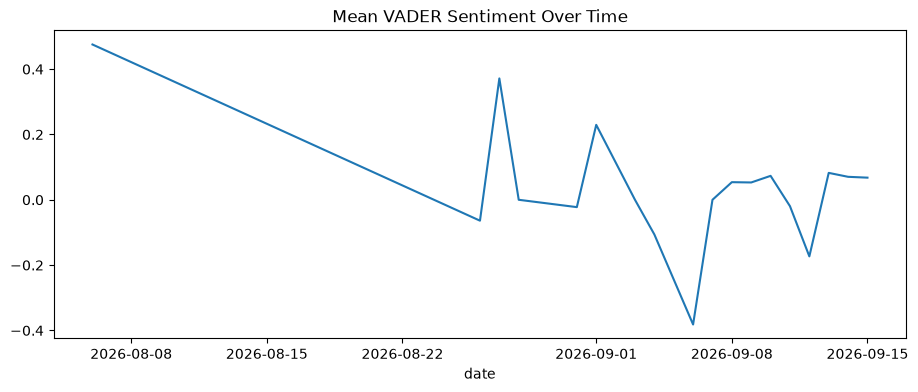

In [5]:
daily = daily_sentiment(sentiment_df, news_df, 'vader')
daily.set_index('date')['mean_sentiment'].plot(figsize=(11, 4), title='Mean VADER Sentiment Over Time')